<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  str    
 3   Marital_Status       56000 non-null  str    
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  str    
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15  NumDealsPurchases    56000 non-null  int64  
 1

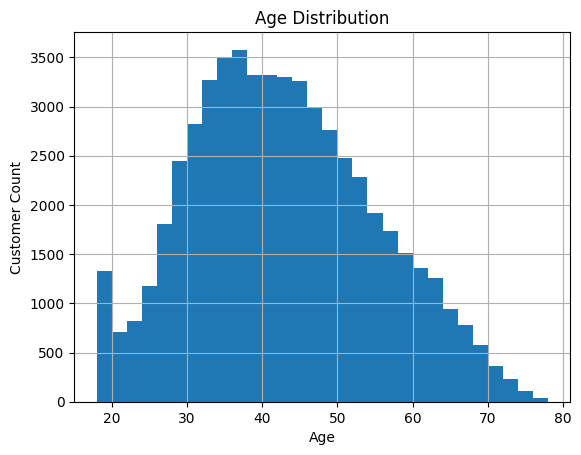

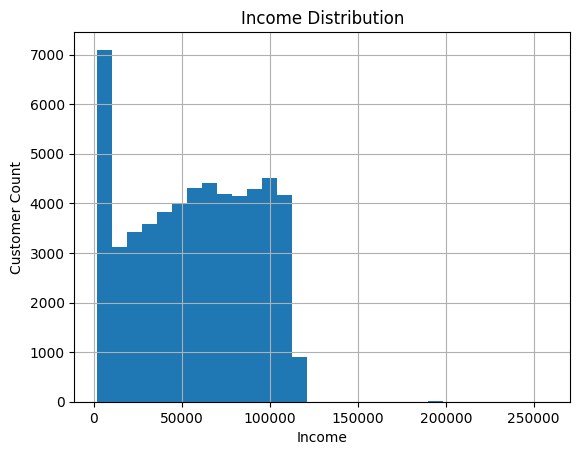

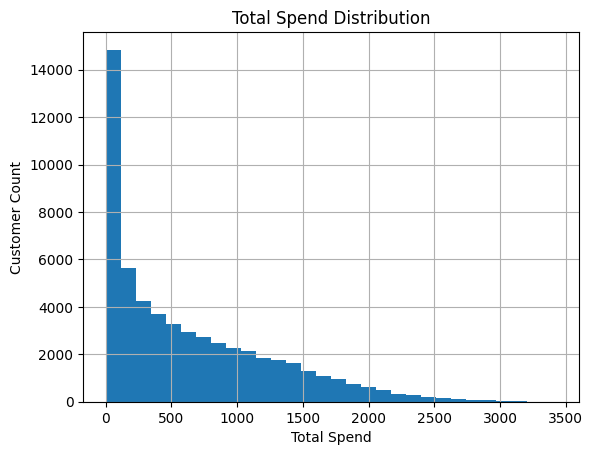

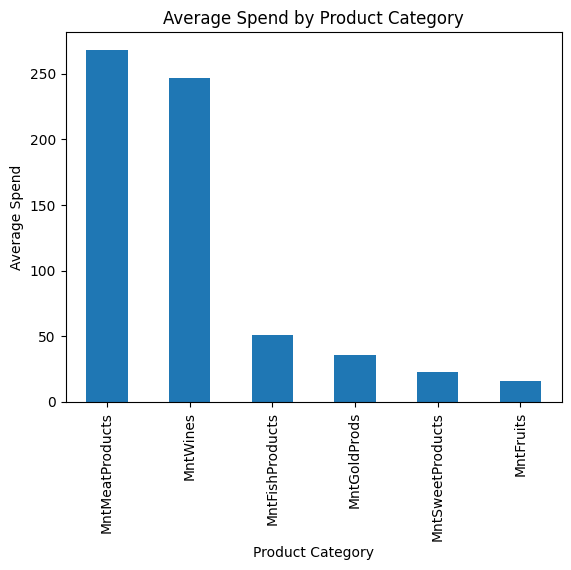

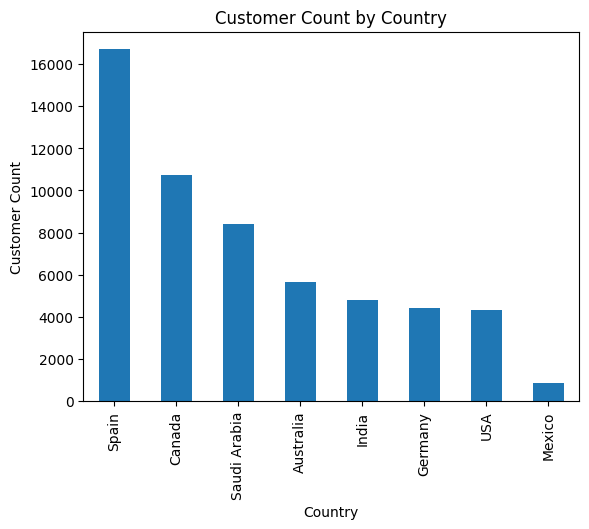

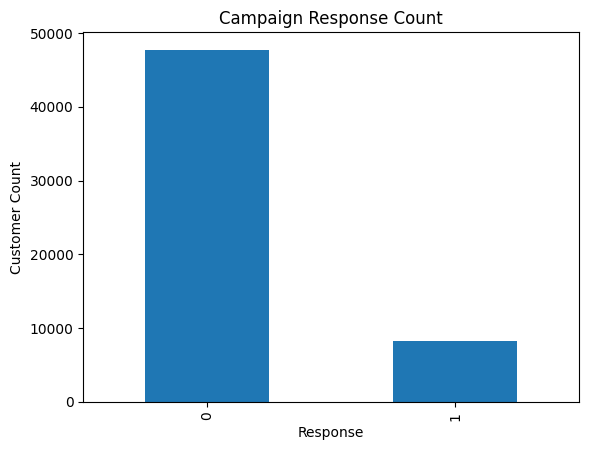

<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  str    
 3   Marital_Status       56000 non-null  str    
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  str    
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15  NumDealsPurchases    56000 non-null  int64  
 1

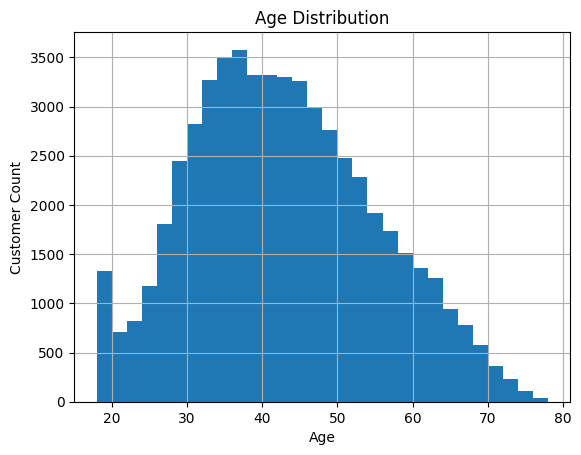

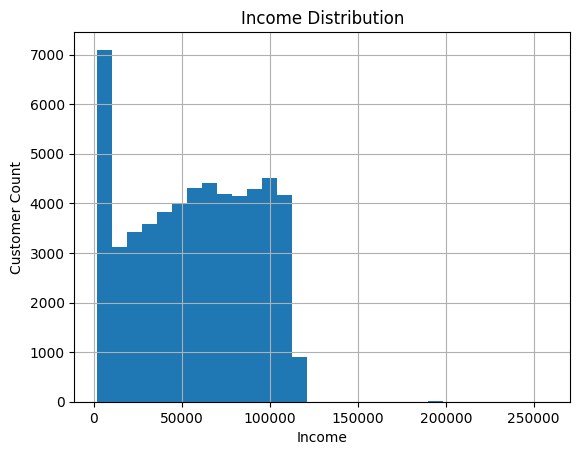

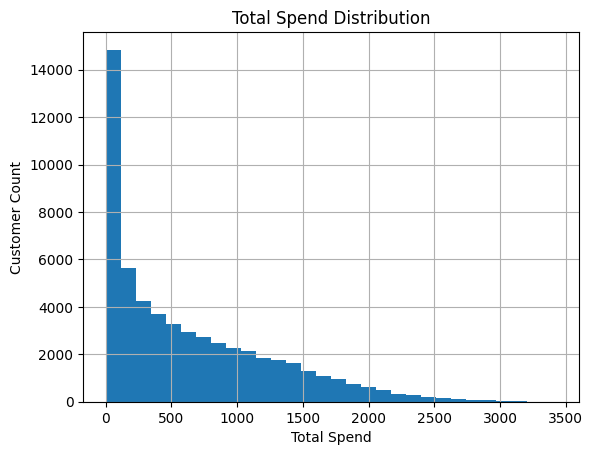

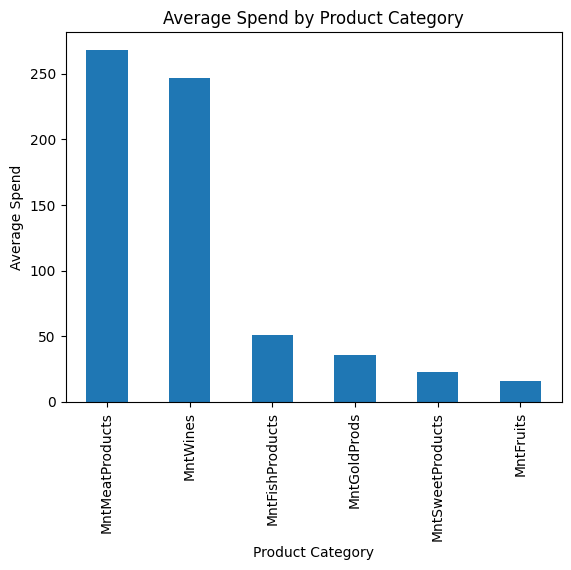

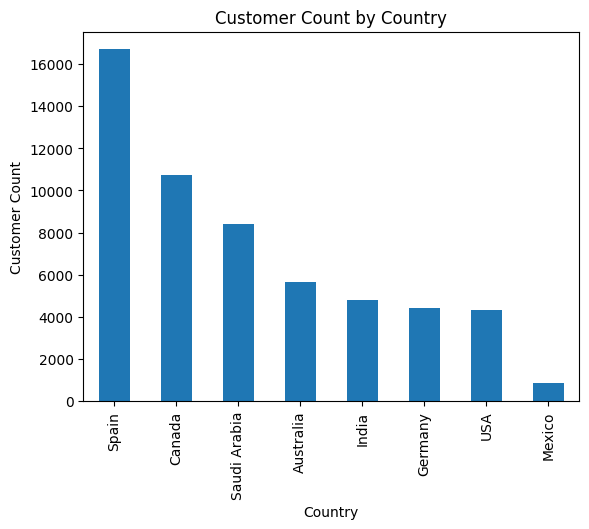

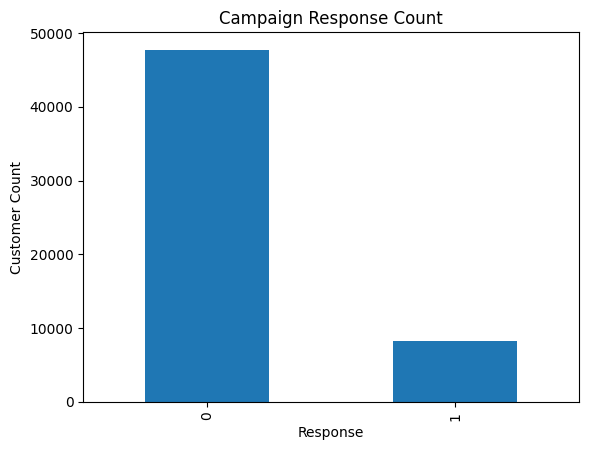

In [13]:
#importing essential libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

#loading both CSV files 
df= pd.read_csv(r"C:\Users\balaj\OneDrive\Desktop\Marketing_Campaign_Analysis\Data\marketing_campaign_data.csv")
dictionary= pd.read_csv(r"C:\Users\balaj\OneDrive\Desktop\Marketing_Campaign_Analysis\Data\marketing_data_dictionary.csv")


df.shape
df.head()
df.info()
dictionary.head()

#Data Understanding

df.columns
df.dtypes
df.describe()
df.nunique()

#Data Quality Check
{
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Duplicate IDs": df["ID"].duplicated().sum()
}
df["Education"].value_counts()
df["Marital_Status"].value_counts()
df["Country"].value_counts()

#Date Conversion
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")
df["Dt_Customer"].min()
df["Dt_Customer"].max()


#Feature Engineering
df["Age"] = 2014 - df["Year_Birth"]

#customer tenure 
reference_date = df ["Dt_Customer"].max()
df["Customer_Tenure_Days"] =(reference_date-df["Dt_Customer"]).dt.days

#Total spend 
spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

df["Total_Spend"] = df[spend_cols].sum(axis=1)

#TTotal purchases 
purchase_cols = [
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases"
]

#Children

df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

df["Children"] = df["Kidhome"] + df["Teenhome"]

#Age Band

df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[0, 29, 45, 60, 100],
    labels=["Under 30", "30-45", "46-60", "60+"]
)


#incomeBand

df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[0, 29, 45, 60, 100],
    labels=["Under 30", "30-45", "46-60", "60+"]
)


#Basic Outlier Check
df["Age"].describe()
df[df["Age"] > 100]

df["Income"].describe()



#Basic EDA Charts

#Age Distribution
df["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customer Count")
plt.show()


#Income Distribution
df["Income"].hist(bins=30)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Customer Count")
plt.show()


#Total Spend Distribution
df["Total_Spend"].hist(bins=30)
plt.title("Total Spend Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Customer Count")
plt.show()


#Product Spend Comparison
df[spend_cols].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Spend by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Spend")
plt.show()


#Country-wise Customer Count
df["Country"].value_counts().plot(kind="bar")
plt.title("Customer Count by Country")
plt.xlabel("Country")
plt.ylabel("Customer Count")
plt.show()


#Campaign Response Count
df["Response"].value_counts().plot(kind="bar")
plt.title("Campaign Response Count")
plt.xlabel("Response")
plt.ylabel("Customer Count")
plt.show()


#Export Cleaned Dataset

#importing essential libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

#loading both CSV files 
df= pd.read_csv(r"C:\Users\balaj\OneDrive\Desktop\Marketing_Campaign_Analysis\Data\marketing_campaign_data.csv")
dictionary= pd.read_csv(r"C:\Users\balaj\OneDrive\Desktop\Marketing_Campaign_Analysis\Data\marketing_data_dictionary.csv")


df.shape
df.head()
df.info()
dictionary.head()

#Data Understanding

df.columns
df.dtypes
df.describe()
df.nunique()

#Data Quality Check
{
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Duplicate IDs": df["ID"].duplicated().sum()
}
df["Education"].value_counts()
df["Marital_Status"].value_counts()
df["Country"].value_counts()

#Date Conversion
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")
df["Dt_Customer"].min()
df["Dt_Customer"].max()


#Feature Engineering
df["Age"] = 2014 - df["Year_Birth"]

#customer tenure 
reference_date = df ["Dt_Customer"].max()
df["Customer_Tenure_Days"] =(reference_date-df["Dt_Customer"]).dt.days

#Total spend 
spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

df["Total_Spend"] = df[spend_cols].sum(axis=1)

#TTotal purchases 
purchase_cols = [
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases"
]

#Children

df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

df["Children"] = df["Kidhome"] + df["Teenhome"]

#Age Band

df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[0, 29, 45, 60, 100],
    labels=["Under 30", "30-45", "46-60", "60+"]
)


#incomeBand

df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[0, 29, 45, 60, 100],
    labels=["Under 30", "30-45", "46-60", "60+"]
)


#Basic Outlier Check
df["Age"].describe()
df[df["Age"] > 100]

df["Income"].describe()



#Basic EDA Charts

#Age Distribution
df["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customer Count")
plt.show()


#Income Distribution
df["Income"].hist(bins=30)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Customer Count")
plt.show()


#Total Spend Distribution
df["Total_Spend"].hist(bins=30)
plt.title("Total Spend Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Customer Count")
plt.show()


#Product Spend Comparison
df[spend_cols].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Spend by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Spend")
plt.show()


#Country-wise Customer Count
df["Country"].value_counts().plot(kind="bar")
plt.title("Customer Count by Country")
plt.xlabel("Country")
plt.ylabel("Customer Count")
plt.show()


#Campaign Response Count
df["Response"].value_counts().plot(kind="bar")
plt.title("Campaign Response Count")
plt.xlabel("Response")
plt.ylabel("Customer Count")
plt.show()


#Export Cleaned Dataset

df.to_csv("../Data/cleaned_marketing_data.csv", index=False)

In [14]:
import pandas as pd
import numpy as np
import os

# Create output folders
os.makedirs("../outputs/day2", exist_ok=True)
os.makedirs("../sql", exist_ok=True)

# Load Day 1 cleaned data
df = pd.read_csv("../data/cleaned_marketing_data.csv")

# Check first 5 rows
df.head()


#checking important colounmns 

needed_columns = [
    "ID", "Income", "Response", "NumWebVisitsMonth",
    "Kidhome", "Teenhome", "Year_Birth",
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases"
]

missing = []

for col in needed_columns:
    if col not in df.columns:
        missing.append(col)

if len(missing) == 0:
    print("All important columns are available.")
else:
    print("Missing columns:", missing)


# Create Required Features Again If Missing

# Create Age if missing
if "Age" not in df.columns:
    df["Age"] = 2014 - df["Year_Birth"]

# Create Children if missing
if "Children" not in df.columns:
    df["Children"] = df["Kidhome"] + df["Teenhome"]

# Product spending columns
spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

# Create Total Spend if missing
if "Total_Spend" not in df.columns:
    df["Total_Spend"] = df[spend_cols].sum(axis=1)

# Purchase channel columns
purchase_cols = [
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases"
]

# Create Total Purchases if missing
if "Total_Purchases" not in df.columns:
    df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

# Create Age Band if missing
if "Age_Band" not in df.columns:
    df["Age_Band"] = pd.cut(
        df["Age"],
        bins=[0, 29, 45, 60, 100],
        labels=["Under 30", "30-45", "46-60", "60+"]
    )

# Create Income Band if missing
if "Income_Band" not in df.columns:
    df["Income_Band"] = pd.cut(
        df["Income"],
        bins=[0, 30000, 60000, 90000, 300000],
        labels=["Low", "Medium", "High", "Very High"]
    )

df.head()




All important columns are available.


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Complain,Country,Age,Customer_Tenure_Days,Total_Spend,Total_Purchases,Children,Age_Band,Income_Band
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,0,0,Spain,29,589,69,13,1,Under 30,Medium
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,0,0,Spain,39,445,39,4,2,30-45,Low
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,0,0,Australia,36,169,1512,12,0,30-45,Very High
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,0,0,Spain,38,11,478,16,1,30-45,High
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,0,0,Canada,33,40,330,9,2,30-45,Medium


In [ ]:
#Create Rule-Based Segments


# Find top 10% spend value
high_spend_limit = df["Total_Spend"].quantile(0.90)

# Create segment columns
df["High_Income"] = (df["Income"] > 75000).astype(int)
df["Young_Customer"] = (df["Age"] < 30).astype(int)
df["Campaign_Responder"] = (df["Response"] == 1).astype(int)
df["High_Web_Engagement"] = (df["NumWebVisitsMonth"] > 5).astype(int)
df["Family_Customer"] = (df["Children"] > 0).astype(int)
df["High_Spender"] = (df["Total_Spend"] > high_spend_limit).astype(int)

# Check segment counts
df[
    [
        "High_Income",
        "Young_Customer",
        "Campaign_Responder",
        "High_Web_Engagement",
        "Family_Customer",
        "High_Spender"
    ]
].sum()



,Segment,Customers,Response_Rate,Average_Income,Average_Spend,Average_Purchases,Average_Web_Visits
0,High_Income,19782,23.54,94997.93,1038.03,16.24,4.34
1,Young_Customer,8285,11.65,51779.08,485.58,12.25,5.45
2,Campaign_Responder,8265,100.00,75317.24,939.29,15.56,4.58
3,High_Web_Engagement,29970,12.07,48626.72,510.08,12.21,7.20
4,Family_Customer,38222,11.62,48493.55,499.70,12.15,5.47
5,High_Spender,5599,26.04,87841.75,1972.20,16.93,4.04


In [28]:
#Create Segment KPI Table

segments = [
    "High_Income",
    "Young_Customer",
    "Campaign_Responder",
    "High_Web_Engagement",
    "Family_Customer",
    "High_Spender"
]

segment_results = []

for segment in segments:
    temp = df[df[segment] == 1]
    
    segment_results.append({
        "Segment": segment,
        "Customers": len(temp),
        "Response_Rate": round(temp["Response"].mean() * 100, 2),
        "Average_Income": round(temp["Income"].mean(), 2),
        "Average_Spend": round(temp["Total_Spend"].mean(), 2),
        "Average_Purchases": round(temp["Total_Purchases"].mean(), 2),
        "Average_Web_Visits": round(temp["NumWebVisitsMonth"].mean(), 2)
    })

segment_kpis = pd.DataFrame(segment_results)
segment_kpis
segment_kpis.to_csv("../outputs/day2/segment_kpis.csv", index=False)

In [29]:
#campaign performance 

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

campaign_results = []

for campaign in campaign_cols:
    campaign_results.append({
        "Campaign": campaign,
        "Accepted_Customers": df[campaign].sum(),
        "Acceptance_Rate": round(df[campaign].mean() * 100, 2)
    })

campaign_performance = pd.DataFrame(campaign_results)
campaign_performance


campaign_performance.to_csv("../outputs/day2/campaign_performance.csv", index=False)

In [30]:
#Product Spending Analysis

product_spend = pd.DataFrame({
    "Product": spend_cols,
    "Total_Spend": [df[col].sum() for col in spend_cols],
    "Average_Spend": [round(df[col].mean(), 2) for col in spend_cols]
})

product_spend = product_spend.sort_values("Total_Spend", ascending=False)
product_spend


product_spend.to_csv("../outputs/day2/product_spend_summary.csv", index=False)

In [31]:
#chanel usage analysis 

channel_cols = [
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

channel_usage = pd.DataFrame({
    "Channel": channel_cols,
    "Total": [df[col].sum() for col in channel_cols],
    "Average": [round(df[col].mean(), 2) for col in channel_cols]
})

channel_usage = channel_usage.sort_values("Average", ascending=False)
channel_usage

channel_usage.to_csv("../outputs/day2/channel_usage_summary.csv", index=False)

In [26]:
# : High-Value Customers


#: High-value customer = High Spender OR High Income + Campaign Responder


df["High_Value_Customer"] = (
    (df["High_Spender"] == 1) |
    ((df["High_Income"] == 1) & (df["Response"] == 1))
).astype(int)

high_value_customers = df[df["High_Value_Customer"] == 1]

high_value_summary = {
    "Total_High_Value_Customers": len(high_value_customers),
    "Average_Income": round(high_value_customers["Income"].mean(), 2),
    "Average_Spend": round(high_value_customers["Total_Spend"].mean(), 2),
    "Response_Rate": round(high_value_customers["Response"].mean() * 100, 2)
}

high_value_summary

high_value_customers.to_csv("../outputs/day2/high_value_customers.csv", index=False)

In [25]:
#Underserved Customer

# Underserved customer = Low spend + high web visits + no response

low_spend_limit = df["Total_Spend"].median()

df["Underserved_Customer"] = (
    (df["Total_Spend"] <= low_spend_limit) &
    (df["NumWebVisitsMonth"] > 5) &
    (df["Response"] == 0)
).astype(int)

underserved_customers = df[df["Underserved_Customer"] == 1]

underserved_summary = {
    "Total_Underserved_Customers": len(underserved_customers),
    "Average_Income": round(underserved_customers["Income"].mean(), 2),
    "Average_Spend": round(underserved_customers["Total_Spend"].mean(), 2),
    "Average_Web_Visits": round(underserved_customers["NumWebVisitsMonth"].mean(), 2)
}

underserved_summary

underserved_customers.to_csv("../outputs/day2/underserved_customers.csv", index=False)

pd.DataFrame([underserved_summary]).to_csv(
    "../outputs/day2/underserved_summary.csv",
    index=False
)

In [23]:
#Response by Income, Age, and Country

#Response by Income Band

response_by_income = df.groupby("Income_Band").agg(
    Customers=("ID", "count"),
    Response_Rate=("Response", "mean"),
    Average_Spend=("Total_Spend", "mean")
).reset_index()

response_by_income["Response_Rate"] = (response_by_income["Response_Rate"] * 100).round(2)
response_by_income["Average_Spend"] = response_by_income["Average_Spend"].round(2)

response_by_income


response_by_income.to_csv("../outputs/day2/response_by_income_band.csv", index=False)

#Response by Age Band
response_by_age = df.groupby("Age_Band").agg(
    Customers=("ID", "count"),
    Response_Rate=("Response", "mean"),
    Average_Spend=("Total_Spend", "mean")
).reset_index()

response_by_age["Response_Rate"] = (response_by_age["Response_Rate"] * 100).round(2)
response_by_age["Average_Spend"] = response_by_age["Average_Spend"].round(2)

response_by_age

response_by_age.to_csv("../outputs/day2/response_by_age_band.csv", index=False)

#response By country 

response_by_country = df.groupby("Country").agg(
    Customers=("ID", "count"),
    Response_Rate=("Response", "mean"),
    Average_Spend=("Total_Spend", "mean")
).reset_index()

response_by_country["Response_Rate"] = (response_by_country["Response_Rate"] * 100).round(2)
response_by_country["Average_Spend"] = response_by_country["Average_Spend"].round(2)

response_by_country = response_by_country.sort_values("Response_Rate", ascending=False)

response_by_country

response_by_country.to_csv("../outputs/day2/response_by_country.csv", index=False)

In [27]:
#Save Updated Cleaned Dataset

df.to_csv("../data/cleaned_marketing_data.csv", index=False)

print("Updated cleaned data saved successfully.")

Updated cleaned data saved successfully.
